<a href="https://colab.research.google.com/github/madanjha/Machine-Learning/blob/main/MarkovChain14thSept2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Markov Chain**
It is a system that moves between states over time. The key property of markov is:


> The probabilty of the next state depends only on the current state, not on the full past



###**For Example**
In a canteen there are three dishes - A,B,C. What get served tomorrow will be depending on today's dish
* States: A,B,C
* Transition: Moving from today's dish(current state) to the tomorrows dish (Next Sate)
* Transition Probabilities: p(A|B) = Probabilty that tomorrow is A given that today is B

##**Convection to Use**
There are two types of convection:
* **Row-stochastic convection ->** In matrix row wise sum = 1
* **Column-stochastic convection ->** In matrix column wise sum = 1

**we are going to use Column-Stochastic convection(column wise sum = 1)**
* Matrix (p): Columns = Current state, rows = next state
* Each columns sum to 1 (Probabilities of where you go from the current)
* state vector (pi_t) = A 3x1 column vector (contain probabilties for state A,B,C at the time t)
* `update rule = pi_t+1 = P x pi_t`

**Matrix P**

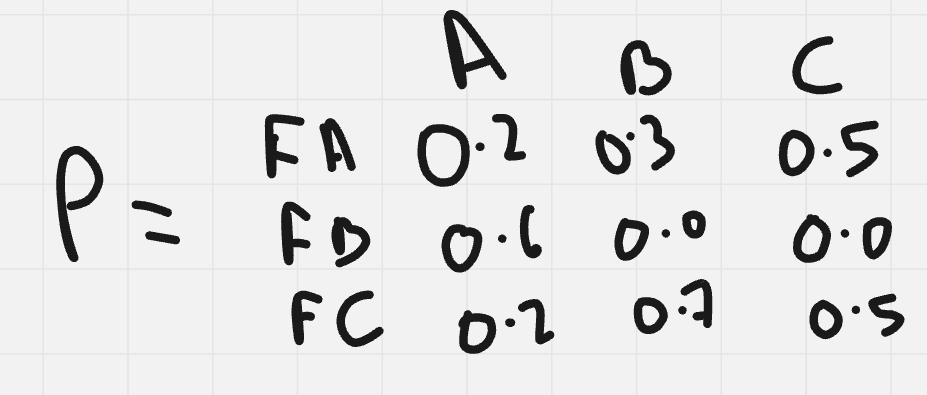

**Current State Vector**

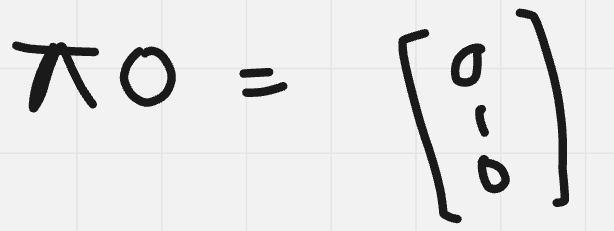

**Updated State Vector**

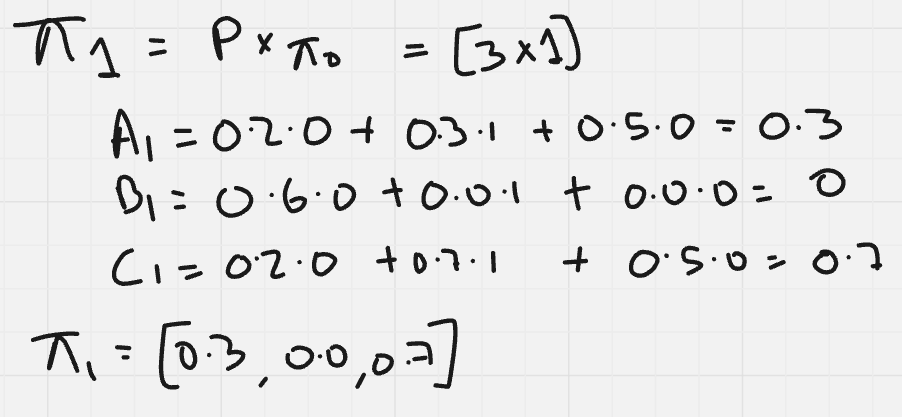

**30% chances are that it would be dish A next dat and 70% chances for C**

**Let's Check for the next state now**

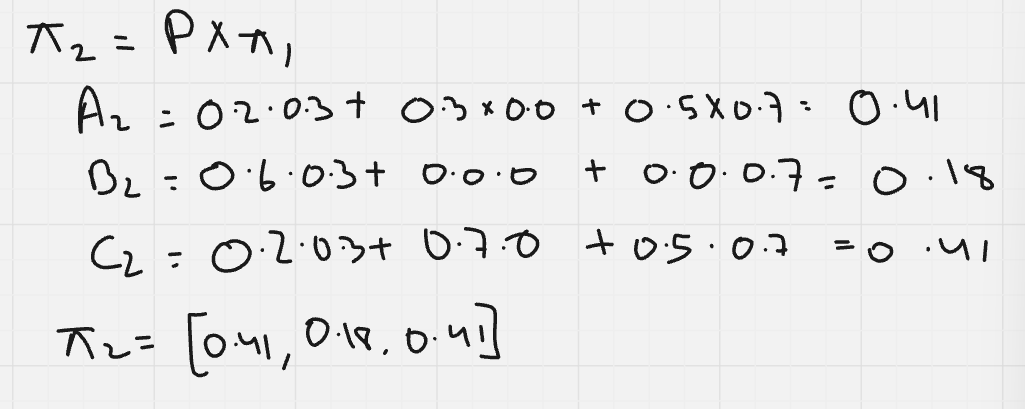

##**n-step transition (Power of the matrix)**
The matrix power (p^n) collects n-steps transition probabilities. (next = i| current = j)

`p^n[i,j] = p(state i after n steps | starts in state j)`



**Steps**

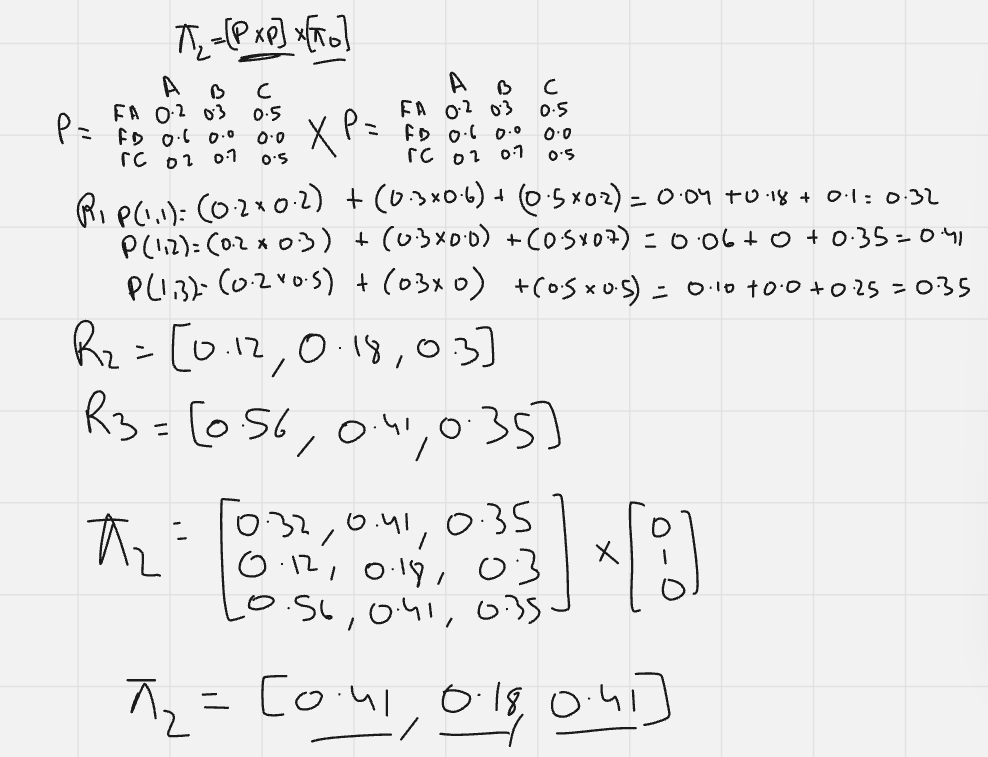

**If we observe, it is same as the previous one**

Let's implement it as a python way

In [ ]:
import numpy as np
P = np.array([
    [0.2,0.3,0.5], # Future A
    [0.6,0.0,0.0], # Future B
    [0.2,0.7,0.5]  # Future C
])

In [ ]:
P

array([[0.2, 0.3, 0.5],
       [0.6, 0. , 0. ],
       [0.2, 0.7, 0.5]])

In [ ]:
pi0 = np.array([0,1,0])
pi1 = P @ pi0
pi1

array([0.3, 0. , 0.7])

**Let's now implement n step method**

In [ ]:
n = 2
pin = np.linalg.matrix_power(P,n) @ pi0
pin

array([0.41, 0.18, 0.41])

##**Stationary Distribution (Equilibrium)**
In longer run, We get stationary distribution (pi*) that is a proability vector does not change under the updates.

`P x pi* = pi*`

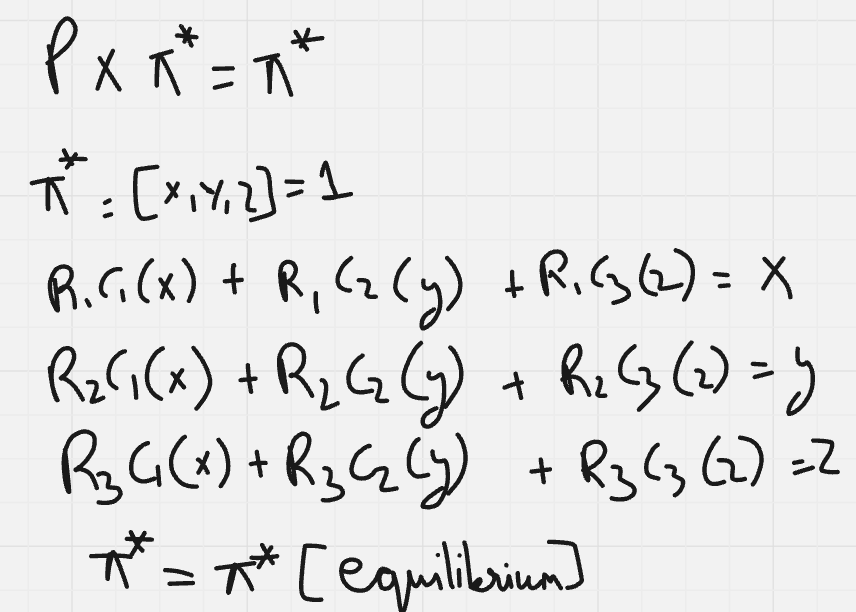

Once we equate all the equations -> X,Y,Z -> normalize it as X+Y+Z = 1 -> Equilibrium

**Let's see the equilibrium using python**

In [ ]:
P

array([[0.2, 0.3, 0.5],
       [0.6, 0. , 0. ],
       [0.2, 0.7, 0.5]])

In [ ]:
eigvals , eigvec = np.linalg.eig(P)

In [ ]:
eigvals

array([ 1.  +0.j       , -0.15+0.3122499j, -0.15-0.3122499j])

In [ ]:
eigvec

array([[-0.58746336+0.j        , -0.16984156+0.35355339j,
        -0.16984156-0.35355339j],
       [-0.35247801+0.j        ,  0.67936622+0.j        ,
         0.67936622-0.j        ],
       [-0.72845456+0.j        , -0.50952467-0.35355339j,
        -0.50952467+0.35355339j]])

In [ ]:
oneIndex = np.argmin(np.abs(eigvals - 1))
oneIndex

np.int64(0)

**Let's extract the vectors related to eigvale[0]**

In [ ]:
type(-0.58746336+0.j   ) # Complex numbers are imaginary number

complex

In [ ]:
stationaryVector = np.real(eigvec[:,oneIndex])

In [ ]:
stationaryNormalized = stationaryVector / stationaryVector.sum()

In [ ]:
stationaryNormalized # pi*

array([0.35211268, 0.21126761, 0.43661972])

**Loop approach to find `pi*`**

In [ ]:
P

array([[0.2, 0.3, 0.5],
       [0.6, 0. , 0. ],
       [0.2, 0.7, 0.5]])

In [ ]:
states = ['A','B','C']

In [ ]:
def markovChain(P, start = 0, step = 100000):
  current = start
  counts = np.zeros(P.shape[0]) # We are creating counter for how many times each state is visited

  for i in range(step):
    current = np.random.choice(len(states),p=P[:,current]) # here we are picking the next state randomly,using the probabilites in column current of P
    counts[current] +=1
  return counts/step

In [ ]:
x = markovChain(P, start = 0, step = 200000)
print(x)

[0.35307  0.210475 0.436455]


In [ ]:
# array([0.35211268, 0.21126761, 0.43661972])

##**pymarkovchain**

In [ ]:
pip install pymarkovchain

  Preparing metadata (setup.py) ... done
  Created wheel for pymarkovchain: filename=PyMarkovChain-1.8-py3-none-any.whl size=4322 sha256=e4cf0f0ae21f6fb19b1de8e3812c8ee09c2812cd2a0d66fa9d06307d61d41086
  Stored in directory: /root/.cache/pip/wheels/0d/2b/37/27274de277251f7027e458b3789215b481ff8118d17a153199
Successfully built pymarkovchain


In [ ]:
P

array([[0.2, 0.3, 0.5],
       [0.6, 0. , 0. ],
       [0.2, 0.7, 0.5]])

In [ ]:
states

['A', 'B', 'C']

**Training Sequence**

In [ ]:
def training_sequence(P, start = 0, step = 1000):
  current = start
  sequence = [states[current]] # Start the sequnce with the inital state name

  for i in range(step):
    current = np.random.choice(len(states),p=P[:,current]) # here we are picking the next state randomly,using the probabilites in column current of P
    sequence.append(states[current])
  return ", ".join(sequence)

**Buliding Training Data**

In [ ]:
trainText = training_sequence(P,start=0,step=10000)

In [ ]:
trainText

'A, B, A, B, C, A, B, C, A, B, C, A, B, C, A, A, B, C, C, A, A, A, B, C, A, B, C, A, B, C, C, C, A, A, C, C, A, B, A, B, C, A, C, A, B, A, A, A, A, B, C, C, C, A, B, A, B, C, C, C, C, C, A, B, A, A, B, A, A, B, C, C, C, A, B, A, B, C, A, B, C, A, B, C, C, C, A, B, A, B, A, B, A, B, C, C, C, C, C, C, A, B, C, A, C, A, C, C, A, B, C, C, C, C, A, A, B, C, C, C, C, A, B, C, C, A, B, C, A, A, B, C, C, A, B, C, A, A, A, B, C, C, C, C, A, B, C, C, A, B, C, A, B, C, A, A, A, C, A, B, A, C, A, A, B, A, B, C, C, C, A, B, C, A, B, C, A, B, C, A, B, C, A, A, B, C, C, A, B, A, B, A, B, C, C, C, A, B, C, A, A, A, C, A, B, C, C, C, C, A, A, A, C, A, B, A, B, A, A, B, C, C, A, B, C, C, A, B, C, A, A, B, A, B, A, C, C, A, A, C, C, A, B, C, C, C, C, A, B, A, B, A, A, B, C, C, C, A, A, B, A, B, C, A, B, C, A, B, C, A, A, A, A, B, C, C, C, C, A, A, A, C, C, C, C, A, B, C, C, C, C, A, B, C, C, A, B, C, C, C, C, A, C, A, B, A, B, C, C, A, A, B, C, C, C, A, C, A, B, A, B, C, A, C, A, B, A, B, C, C, C, C, A, 

In [ ]:
with open('training_data.txt','w') as f:
  f.write(trainText)

**Let's implement markov chain**

In [ ]:
from pymarkovchain import MarkovChain

In [ ]:
mc = MarkovChain()
mc.generateDatabase(trainText)

In [ ]:
mc.generateString()

KeyboardInterrupt: 